# Google Colab Tutorial and Sierra Mercury DataSet

## Research Question

How does mercury associated with historical mining move through aquatic ecosystems?

Specifically:
- How does mercury differ between water, sediment, and organisms?
- Do higher organisms (like fish) show evidence of bioaccumulation?

## Key Terms

- **Total Mercury (THg):** All mercury measured in a sample
- **Methylmercury (MeHg):** Toxic form that accumulates in organisms
- **Bioaccumulation:** Increase of a substance within an organism over time
- **Biomagnification:** Increase in concentration across trophic levels

Google Colab tutorial: Sierra Nevada mercury dataset
1) Create a new Colab notebook

Go to Google Colab and create a blank notebook.

Initial datasets of interest located here: https://www.sciencebase.gov/catalog/item/5f91e00782ce720ee2d33c5b


## In the first code cell, paste this:

In [53]:
# ============================================================
# USGS Mercury Dataset Starter Notebook
# Historical mining, Sierra Nevada / Trinity Mountains, CA
# ============================================================

#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import folium
import zipfile
import io
import os
import re

# ============================================================

#define functions
def inspect_column(df, col):
    print(f"\nColumn: {col}")
    print(df[col].head(10))
    print("\nData type:", df[col].dtype)
    print("\nUnique examples:")
    print(df[col].dropna().astype(str).head(20).tolist())

def find_mercury_columns(df, name):
    cols = [c for c in df.columns if any(k in c.lower() for k in ["hg", "mercury", "mehg", "methyl"])]
    print(f"\n{name} mercury-related columns:")
    for c in cols:
        print(" -", c)

def clean_numeric_value(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if x in ["", "NA", "ND", "nan", "None"]:
        return np.nan

    # Remove censoring symbols like < or >
    x = re.sub(r"[<>]", "", x)
    x = x.replace(",", "")

    try:
        return float(x)
    except:
        return np.nan

def add_clean_columns(df, column_dict, suffix="_clean"):
    for short_name, original_col in column_dict.items():
        df[short_name + suffix] = df[original_col].apply(clean_numeric_value)

def count_clean_values(df, name):
    print(f"\n{name}")
    for col in [c for c in df.columns if c.endswith("_clean")]:
        print(f"{col}: {df[col].notna().sum()} non-null values")

def classify_region(row):
    lat = row["Latitude"]
    lon = row["Longitude"]

    if lat > 40.5 and lon < -122.3:
        return "Trinity Mountains (Hard-rock Hg)"
    elif lat > 38.9:
        return "Sierra Nevada Mining (Gold Rush)"
    else:
        return "Downstream Watersheds"
# ============================================================

# Make plots a little larger and easier to read
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# ============================================================

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
#Download all the datasets

item_url = "https://www.sciencebase.gov/catalog/item/5f91e00782ce720ee2d33c5b?format=json"
out_dir = "usgs_mercury_data"
os.makedirs(out_dir, exist_ok=True)

meta = requests.get(item_url, timeout=120)
meta.raise_for_status()
data = meta.json()

for file_info in data["files"]:
    name = file_info["name"]
    url = file_info["downloadUri"]
    print(f"Downloading {name} ...")

    r = requests.get(url, timeout=120)
    r.raise_for_status()

    path = os.path.join(out_dir, name)
    with open(path, "wb") as f:
        f.write(r.content)

    print(f"  saved {name} ({len(r.content):,} bytes)")

  saved T1_Data_Dictionary.csv (54,825 bytes)
  saved T2_Study_Sites.csv (21,285 bytes)
  saved T3_Water_Mercury.csv (37,091 bytes)
  saved T4_Sediment_Mercury.csv (25,317 bytes)
  saved T5_Invertebrates_Mercury.csv (107,983 bytes)
  saved T6_Frogs_Mercury.csv (40,955 bytes)
  saved T7_Fish_Mercury.csv (14,731 bytes)
  saved T8_Water_FieldParameters.csv (23,540 bytes)
  saved T9_Water_Isotopes_Nutrients_MajorIons.csv (38,654 bytes)
  saved T10_Water_TraceElements_Filtered.csv (81,182 bytes)
  saved T11_Water_TraceElements_Unfiltered.csv (90,201 bytes)
  saved T12_Sediment_TraceElements.csv (8,715 bytes)
  saved T13_Invertebrates_TraceElements.csv (3,724 bytes)
  saved T14_Fish_TraceElements.csv (2,432 bytes)
  saved T15_GeometricMean_MercuryConcentrations.csv (31,825 bytes)
  saved T16_Normalized_Mercury_Values.csv (23,088 bytes)
  saved Geochem_Data_Historic_Mining.xml (26,182 bytes)
  saved Relief Hill_2014.jpg (3,668,757 bytes)


In [10]:
#Load all the data tables
data_dir = "usgs_mercury_data"
base = "usgs_mercury_data"

tables = {}
for fname in os.listdir(data_dir):
    if fname.lower().endswith(".csv"):
        path = os.path.join(data_dir, fname)
        key = os.path.splitext(fname)[0]
        tables[key] = pd.read_csv(path)

print("Loaded tables:")
for k, df in tables.items():
    print(f"{k}: {df.shape}")

Loaded tables:
T9_Water_Isotopes_Nutrients_MajorIons: (226, 25)
T8_Water_FieldParameters: (190, 15)
T5_Invertebrates_Mercury: (613, 16)
T15_GeometricMean_MercuryConcentrations: (250, 16)
T13_Invertebrates_TraceElements: (11, 36)
T3_Water_Mercury: (263, 15)
T12_Sediment_TraceElements: (22, 58)
T11_Water_TraceElements_Unfiltered: (232, 62)
T10_Water_TraceElements_Filtered: (207, 60)
T1_Data_Dictionary: (397, 6)
T6_Frogs_Mercury: (231, 16)
T16_Normalized_Mercury_Values: (218, 9)
T14_Fish_TraceElements: (6, 35)
T4_Sediment_Mercury: (203, 12)
T2_Study_Sites: (250, 5)
T7_Fish_Mercury: (83, 17)


In [11]:
tables["T6_Frogs_Mercury"].head()
tables["T2_Study_Sites"].head()

,Station Map ID,USGS Station Name,USGS Station Number,Latitude,Longitude
0,AR-01,CANYON C BL GOLD RUN TUNNEL OUTLET NR GOLD RUN CA,390945120502401,39.16156,-120.84049
1,AR-02,CANYON C AB GOLD RUN TUNNEL OUTLET NR GOLD RUN CA,390945120502402,39.16351,-120.84022
2,AR-03,GOLD RUN TUNNEL OUTLET NR COLFAX CA,390945120562001,39.16240,-120.84161
3,AR-05,GOLD RUN MINE POND NR INDIANA RAVINE NR GOLD RUN,390932120504601,39.15879,-120.84716
4,AR-06,KEYSTONE MINE TUNNEL OUTLET NR FORRESTHILLS CA,390305120500301,39.05139,-120.83417


In [12]:
#Name some analysis variables of interest
sites = pd.read_csv(os.path.join(base, "T2_Study_Sites.csv"))
water = pd.read_csv(os.path.join(base, "T3_Water_Mercury.csv"))
sediment = pd.read_csv(os.path.join(base, "T4_Sediment_Mercury.csv"))
invert = pd.read_csv(os.path.join(base, "T5_Invertebrates_Mercury.csv"))
frogs = pd.read_csv(os.path.join(base, "T6_Frogs_Mercury.csv"))
fish = pd.read_csv(os.path.join(base, "T7_Fish_Mercury.csv"))
geo_mean = pd.read_csv(os.path.join(base, "T15_GeometricMean_MercuryConcentrations.csv"))

#Examine tables called by variable names
print("Loaded core tables.")
print("sites:", sites.shape)
print("water:", water.shape)
print("sediment:", sediment.shape)
print("frogs:", frogs.shape)
print("invert:", invert.shape)
print("fish:", fish.shape)
print("geo_mean:", geo_mean.shape)

Loaded core tables.
sites: (250, 5)
water: (263, 15)
sediment: (203, 12)
frogs: (231, 16)
invert: (613, 16)
fish: (83, 17)
geo_mean: (250, 16)


Notice the data table output:

T6_Frogs_Mercury: (231, 16)

T7_Fish_Mercury: (83, 17)

There's more frog data than fish data... That's interesting

In [13]:
print(sites.columns.tolist())
sites.head()

['Station Map ID', 'USGS Station Name', 'USGS Station Number', 'Latitude', 'Longitude']


,Station Map ID,USGS Station Name,USGS Station Number,Latitude,Longitude
0,AR-01,CANYON C BL GOLD RUN TUNNEL OUTLET NR GOLD RUN CA,390945120502401,39.16156,-120.84049
1,AR-02,CANYON C AB GOLD RUN TUNNEL OUTLET NR GOLD RUN CA,390945120502402,39.16351,-120.84022
2,AR-03,GOLD RUN TUNNEL OUTLET NR COLFAX CA,390945120562001,39.16240,-120.84161
3,AR-05,GOLD RUN MINE POND NR INDIANA RAVINE NR GOLD RUN,390932120504601,39.15879,-120.84716
4,AR-06,KEYSTONE MINE TUNNEL OUTLET NR FORRESTHILLS CA,390305120500301,39.05139,-120.83417


In [15]:
# Make a copy
sites_map = sites.copy()

# Show columns so you can confirm names
print("Columns in sites table:")
print(sites_map.columns.tolist())

# Try to identify latitude/longitude columns automatically
lat_col = None
lon_col = None

for col in sites_map.columns:
    c = col.lower()
    if lat_col is None and "lat" in c:
        lat_col = col
    if lon_col is None and ("lon" in c or "long" in c):
        lon_col = col

print("\nDetected coordinate columns:")
print("Latitude column:", lat_col)
print("Longitude column:", lon_col)

# Drop rows missing coordinates
sites_map = sites_map.dropna(subset=[lat_col, lon_col]).copy()

# Convert to numeric just in case
sites_map[lat_col] = pd.to_numeric(sites_map[lat_col], errors="coerce")
sites_map[lon_col] = pd.to_numeric(sites_map[lon_col], errors="coerce")
sites_map = sites_map.dropna(subset=[lat_col, lon_col])

# Center the map on the average location
center_lat = sites_map[lat_col].mean()
center_lon = sites_map[lon_col].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles="OpenStreetMap")

# Pick a likely label column if present
label_candidates = ["SiteID", "Site_ID", "Site Name", "SiteName", "Station", "StationName", "Location"]
label_col = None
for candidate in label_candidates:
    if candidate in sites_map.columns:
        label_col = candidate
        break

# Add markers
for _, row in sites_map.iterrows():
    label = str(row[label_col]) if label_col else "Site"

    popup_text = "<br>".join([f"<b>{col}</b>: {row[col]}" for col in sites_map.columns])

    folium.CircleMarker(
        location=[row[lat_col], row[lon_col]],
        radius=6,
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=label,
        fill=True
    ).add_to(m)

m

Columns in sites table:
['Station Map ID', 'USGS Station Name', 'USGS Station Number', 'Latitude', 'Longitude']

Detected coordinate columns:
Latitude column: Latitude
Longitude column: Longitude


In [16]:
m.save("station_map.html")
print("Saved interactive map to station_map.html")

Saved interactive map to station_map.html


In [17]:
from folium.plugins import MarkerCluster

m = folium.Map(location=[center_lat, center_lon], zoom_start=10, tiles="OpenStreetMap")
marker_cluster = MarkerCluster().add_to(m)

for _, row in sites_map.iterrows():
    label = str(row[label_col]) if label_col else "Site"
    popup_text = "<br>".join([f"<b>{col}</b>: {row[col]}" for col in sites_map.columns])

    folium.Marker(
        location=[row[lat_col], row[lon_col]],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=label
    ).add_to(marker_cluster)

m

In [21]:
#Determine different column parameters (to distinguishe between type)
for col in sites.columns:
    print(col, ":", sites[col].dropna().unique()[:10])

Station Map ID : ['AR-01' 'AR-02' 'AR-03' 'AR-05' 'AR-06' 'AR-07' 'AR-09' 'AR-10' 'AR-11'
 'AR-12']
USGS Station Name : ['CANYON C BL GOLD RUN TUNNEL OUTLET NR GOLD RUN CA'
 'CANYON C AB GOLD RUN TUNNEL OUTLET NR GOLD RUN CA'
 'GOLD RUN TUNNEL OUTLET NR COLFAX CA'
 'GOLD RUN MINE POND NR INDIANA RAVINE NR GOLD RUN'
 'KEYSTONE MINE TUNNEL OUTLET NR FORRESTHILLS CA'
 'GLEESON DIGGINGS MAIN SLUICE CUT NR IOWA HILL CA'
 'JUPITER MINE TUNNEL MIDWAY A SLUICE CUT' 'AMERICAN R A FAIR OAKS CA'
 'ALDER C POND A HWY 50 A NIMBUS CA'
 'ALDER C A PRAIRIE CITY RD NR FOLSOM CA']
USGS Station Number : [390945120502401 390945120502402 390945120562001 390932120504601
 390305120500301 390455120510601 390629120515001        11446500
 383809121121601 383824121091601]
Latitude : [39.16156 39.16351 39.1624  39.15879 39.05139 39.08184 39.10795 38.63546
 38.63574 38.6399 ]
Longitude : [-120.84049 -120.84022 -120.84161 -120.84716 -120.83417 -120.85272
 -120.86494 -121.22773 -121.2055  -121.1555 ]


In [54]:
#defines the region by type using the classify_region function
sites["Region"] = sites.apply(classify_region, axis=1)

In [55]:
#inspect site counts
sites["Region"].value_counts()

,count
Region,
Sierra Nevada Mining (Gold Rush),203
Trinity Mountains (Hard-rock Hg),30
Downstream Watersheds,17


In [56]:
sites_map = sites.copy()

# Center map
center_lat = sites_map["Latitude"].mean()
center_lon = sites_map["Longitude"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles="OpenStreetMap")

# Color scheme
color_dict = {
    "Trinity Mountains (Hard-rock Hg)": "purple",
    "Sierra Nevada Mining (Gold Rush)": "red",
    "Downstream Watersheds": "blue"
}

# Add markers (NO clustering)
for _, row in sites_map.iterrows():

    region = row["Region"]
    color = color_dict.get(region, "gray")

    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        tooltip=f"{row['Station Map ID']} ({region})"
    ).add_to(m)

# Fit map to bounds (important for wide datasets)
m.fit_bounds([
    [sites_map["Latitude"].min(), sites_map["Longitude"].min()],
    [sites_map["Latitude"].max(), sites_map["Longitude"].max()]
])

# Legend
legend_html = '''
<div style="
position: fixed;
bottom: 50px; left: 50px; width: 260px; height: 120px;
background-color: white;
border:2px solid grey; z-index:9999; font-size:14px;
padding: 10px;
">
<b>Study Regions</b><br>
<span style="color:purple;">●</span> Trinity Mountains<br>
<span style="color:red;">●</span> Sierra Nevada Mining<br>
<span style="color:blue;">●</span> Downstream Watersheds
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

m

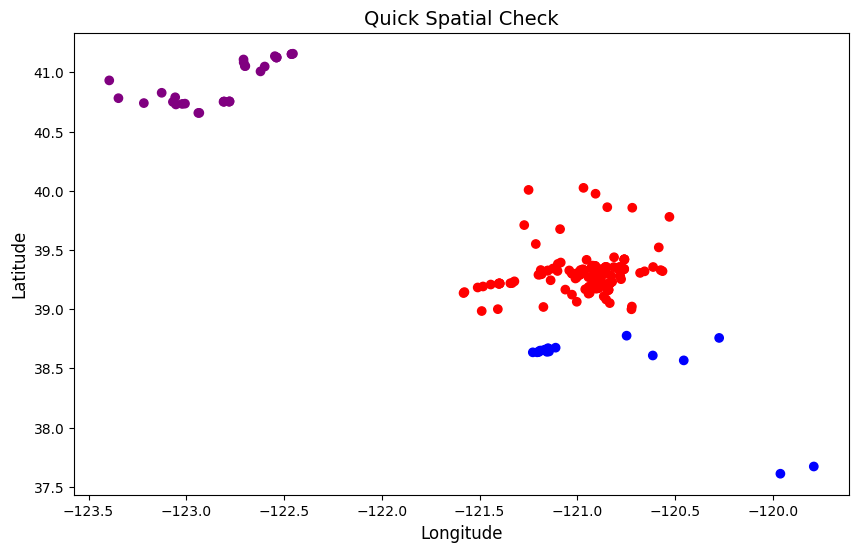

In [57]:
import matplotlib.pyplot as plt

plt.scatter(sites["Longitude"], sites["Latitude"], c=sites["Region"].map(color_dict))
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Quick Spatial Check")
plt.show()

In [58]:
#Merge frogs with site locations
frogs_map = frogs.merge(
    sites[["Station Map ID", "Latitude", "Longitude", "Region"]],
    left_on="Station Map ID",
    right_on="Station Map ID",
    how="left"
)

print(frogs_map.shape)
frogs_map.head()

(231, 19)


,Station Map ID,USGS Station Name,USGS Station Number,Date,Sample Type,Data References,Common Name,Genus and Species,Sample Size,Live Weight (g),Sample Weight (g),Total Length (mm),Moisture (percent),"Total Mercury, Wet (micrograms/g)",Age,Gender,Latitude,Longitude,Region
0,BR-60,SF GREENHORN C .8 MI AB GREENHORN C NR NEVADA ...,3.914050e+14,9/13/2001,Environmental,https://doi.org/10.3133/sir20045251,Foothill yellow-legged frog,Rana boylii,1,40.4,38.7,72.7,72.7,0.19,Adult,Female,39.23462,-120.89244,Sierra Nevada Mining (Gold Rush)
1,BR-60,SF GREENHORN C .8 MI AB GREENHORN C NR NEVADA ...,3.914050e+14,9/13/2001,Environmental,https://doi.org/10.3133/sir20045251,Foothill yellow-legged frog,Rana boylii,1,15.2,14,51,76.3,0.11,Adult,Female,39.23462,-120.89244,Sierra Nevada Mining (Gold Rush)
2,AR-02,CANYON C AB GOLD RUN TUNNEL OUTLET NR GOLD RUN CA,3.909450e+14,6/27/2002,Environmental,NP,Foothill yellow-legged frog,Rana boylii,1,ND,5.8,39.1,83.9,0.044,Juvenile,ND,39.16351,-120.84022,Sierra Nevada Mining (Gold Rush)
3,AR-02,CANYON C AB GOLD RUN TUNNEL OUTLET NR GOLD RUN CA,3.909450e+14,6/27/2002,Environmental,NP,Foothill yellow-legged frog,Rana boylii,1,ND,3.9,34,81.2,0.051,Juvenile,Male,39.16351,-120.84022,Sierra Nevada Mining (Gold Rush)
4,AR-03,GOLD RUN TUNNEL OUTLET NR COLFAX CA,3.909450e+14,6/27/2002,Environmental,NP,Foothill yellow-legged frog,Rana boylii,1,ND,4,36.6,79.7,0.057,Juvenile,ND,39.16240,-120.84161,Sierra Nevada Mining (Gold Rush)


In [79]:
#Check column names of frog data
print(frogs.columns)

Index(['Station Map ID', 'USGS Station Name', 'USGS Station Number', 'Date',
       'Sample Type', 'Data References', 'Common Name', 'Genus and Species',
       'Sample Size', 'Live Weight (g)', 'Sample Weight (g)',
       'Total Length (mm)', 'Moisture (percent)',
       'Total Mercury, Wet (micrograms/g)', 'Age ', 'Gender'],
      dtype='object')


In [80]:
# Replace this with actual column name interested in
hg_col = "Total Mercury, Wet (micrograms/g)"

# Drop missing values
df = frogs_map.dropna(subset=[hg_col, "Latitude", "Longitude"])

#recompile
df[hg_col] = pd.to_numeric(df[hg_col], errors="coerce")

# Normalize for marker size
max_hg = df[hg_col].max()

m = folium.Map(
    location=[df["Latitude"].mean(), df["Longitude"].mean()],
    zoom_start=7
)

color_dict = {
    "Trinity Mountains (Hard-rock Hg)": "purple",
    "Sierra Nevada Mining (Gold Rush)": "red",
    "Downstream Watersheds": "blue"
}

for _, row in df.iterrows():

    size = 5 + 20 * (row[hg_col] / max_hg)  # scale size

    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=size,
        color=color_dict.get(row["Region"], "gray"),
        fill=True,
        fill_opacity=0.7,
        popup=f"""
        <b>Hg:</b> {row[hg_col]:.3f}<br>
        <b>Region:</b> {row['Region']}
        """
    ).add_to(m)

m

Checking to see if they checked any frogs in the blue area

In [81]:
frogs_map["Region"].value_counts()

,count
Region,
Sierra Nevada Mining (Gold Rush),197
Trinity Mountains (Hard-rock Hg),34


Nope no frogs... Hmmm... What about invertebrates

In [82]:
invert_map = invert.merge(
    sites[["Station Map ID", "Latitude", "Longitude", "Region"]],
    on="Station Map ID",
    how="left"
)

invert_map["Region"].value_counts()

,count
Region,
Sierra Nevada Mining (Gold Rush),484
Trinity Mountains (Hard-rock Hg),129


Nope no invertebrates... OK well they must have water samples from all:

In [83]:
water_map = water.merge(
    sites[["Station Map ID", "Latitude", "Longitude", "Region"]],
    on="Station Map ID",
    how="left"
)

water_map["Region"].value_counts()

,count
Region,
Sierra Nevada Mining (Gold Rush),224
Downstream Watersheds,20
Trinity Mountains (Hard-rock Hg),19


Great... And let's check sediment

In [84]:
sediment_map = sediment.merge(
    sites[["Station Map ID", "Latitude", "Longitude", "Region"]],
    on="Station Map ID",
    how="left"
)

sediment_map["Region"].value_counts()

,count
Region,
Sierra Nevada Mining (Gold Rush),160
Trinity Mountains (Hard-rock Hg),25
Downstream Watersheds,16


In [85]:
#look at column names
print(water.columns)
print(sediment.columns)

Index(['Station Map ID', 'USGS Station Name', 'USGS Station Number', 'Date',
       'Time', 'Sample Type', 'Data References', 'Mercury, Unfiltered (ng/L)',
       'Mercury, Unfiltered Data Source', 'Mercury, Filtered (ng/L)',
       'Mercury, Filtered Data Source', 'Methylmercury, Unfiltered (ng/L)',
       'Methylmercury, Unfiltered Data Source',
       'Methylmercury, Filtered (ng/L)',
       'Methylmercury, Filtered Data Source'],
      dtype='object')
Index(['Station Map ID', 'USGS Station Name', 'USGS Station Number', 'Date ',
       'Time', 'Sample Type', 'Data References', 'Total Mercury, Dry (ng/g)',
       'Total Mercury Data Source', 'Methylmercury, Dry (ng/g)',
       'Methylmercury Data Source', 'Loss On Ignition (percent)'],
      dtype='object')


In [92]:
#Checking water column
hg_col = "Mercury, Unfiltered (ng/L)"

df = water_map.copy()
df[hg_col] = pd.to_numeric(df[hg_col], errors="coerce")
df = df.dropna(subset=[hg_col, "Latitude", "Longitude"])

max_hg = df[hg_col].max()

m = folium.Map(
    location=[df["Latitude"].mean(), df["Longitude"].mean()],
    zoom_start=7
)

color_dict = {
    "Trinity Mountains (Hard-rock Hg)": "purple",
    "Sierra Nevada Mining (Gold Rush)": "red",
    "Downstream Watersheds": "blue"
}

for _, row in df.iterrows():

    size = 5 + 20 * (row[hg_col] / max_hg)  # scale size

    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=size,
        color=color_dict.get(row["Region"], "gray"),
        fill=True,
        fill_opacity=0.7,
        popup=f"""
        <b>Hg:</b> {row[hg_col]:.3f}<br>
        <b>Region:</b> {row['Region']}
        """
    ).add_to(m)

m


In [93]:
# Merge sediment with site coordinates + region
sediment_map = sediment.merge(
    sites[["Station Map ID", "Latitude", "Longitude", "Region"]],
    on="Station Map ID",
    how="left"
)

# Mercury column
hg_col = "Total Mercury, Dry (ng/g)"

# Make working copy
df = sediment_map.copy()

# Convert mercury to numeric
df[hg_col] = pd.to_numeric(df[hg_col], errors="coerce")

# Drop rows missing key values
df = df.dropna(subset=[hg_col, "Latitude", "Longitude", "Region"]).copy()

# Optional: remove non-positive values if needed
df = df[df[hg_col] > 0].copy()

# Map center
center_lat = df["Latitude"].mean()
center_lon = df["Longitude"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=7, tiles="OpenStreetMap")

# Region colors
color_dict = {
    "Trinity Mountains (Hard-rock Hg)": "purple",
    "Sierra Nevada Mining (Gold Rush)": "red",
    "Downstream Watersheds": "blue"
}

# Use sqrt scaling so one extreme value does not dominate everything
max_hg = df[hg_col].max()

for _, row in df.iterrows():
    size = 4 + 14 * np.sqrt(row[hg_col] / max_hg)

    popup_text = f"""
    <b>Station ID:</b> {row['Station Map ID']}<br>
    <b>Region:</b> {row['Region']}<br>
    <b>Total Mercury, Dry:</b> {row[hg_col]:,.2f} ng/g<br>
    <b>Latitude:</b> {row['Latitude']:.5f}<br>
    <b>Longitude:</b> {row['Longitude']:.5f}
    """

    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=size,
        color=color_dict.get(row["Region"], "gray"),
        fill=True,
        fill_color=color_dict.get(row["Region"], "gray"),
        fill_opacity=0.7,
        weight=1,
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=f"{row['Station Map ID']}: {row[hg_col]:,.1f} ng/g"
    ).add_to(m)

# Fit map to all points
m.fit_bounds([
    [df["Latitude"].min(), df["Longitude"].min()],
    [df["Latitude"].max(), df["Longitude"].max()]
])

# Build example size legend using real values
q25 = df[hg_col].quantile(0.25)
q50 = df[hg_col].quantile(0.50)
q75 = df[hg_col].quantile(0.75)

def radius_from_value(v, vmax):
    return 4 + 14 * np.sqrt(v / vmax)

r25 = radius_from_value(q25, max_hg)
r50 = radius_from_value(q50, max_hg)
r75 = radius_from_value(q75, max_hg)

legend_html = f"""
<div style="
position: fixed;
bottom: 40px;
left: 40px;
width: 300px;
background-color: white;
border: 2px solid gray;
z-index: 9999;
font-size: 14px;
padding: 12px;
box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
">
<b>Sediment Total Mercury Map</b><br>
<span style="font-size:12px;">Circle color = study region<br>
Circle size = Total Mercury, Dry (ng/g)</span>
<hr style="margin:8px 0;">
<b>Regions</b><br>
<span style="color:purple;">●</span> Trinity Mountains (Hard-rock Hg)<br>
<span style="color:red;">●</span> Sierra Nevada Mining (Gold Rush)<br>
<span style="color:blue;">●</span> Downstream Watersheds<br>
<hr style="margin:8px 0;">
<b>Example circle sizes</b><br>
<span style="display:inline-block; width:{2*r25:.0f}px; height:{2*r25:.0f}px; border-radius:50%; background:#999; opacity:0.6; vertical-align:middle;"></span>
&nbsp; {q25:,.1f} ng/g<br><br>
<span style="display:inline-block; width:{2*r50:.0f}px; height:{2*r50:.0f}px; border-radius:50%; background:#999; opacity:0.6; vertical-align:middle;"></span>
&nbsp; {q50:,.1f} ng/g<br><br>
<span style="display:inline-block; width:{2*r75:.0f}px; height:{2*r75:.0f}px; border-radius:50%; background:#999; opacity:0.6; vertical-align:middle;"></span>
&nbsp; {q75:,.1f} ng/g
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))

m